# <h1 align = 'center'> Hand Written Digit Classification </h1>
<p align = 'center'> K M Shariat Ullah </p>

This notebook uses the `MNIST` dataset to classify hand written digits. It uses Convolutional Neural Network (CNN) as the training model. This notebook has the feature to manually upload an image of a hand written digit and test the model's accuracy.

The MNIST dataset has 70000 images of 28*28 pixels of hand written digits. We'll split this dataset in traning set and testing set. All the digit's are already labeled and hence it is supervised learning.

## Basic Working Principle Behind Neural Networks

Neural Networks (NNs) are computational models inspired by the structure and function of the human brain. They consist of interconnected neurons or nodes, which are linked by connections called edges. A neural network is composed of three main types of layers:

- Input Layer: Receives raw data and passes it to the next layer.
- Hidden Layers: Perform mathematical transformations on the input using weighted connections, biases and activation functions to extract patterns and features.
- Output Layer: Produces the final prediction, often representing probabilities in classification tasks.

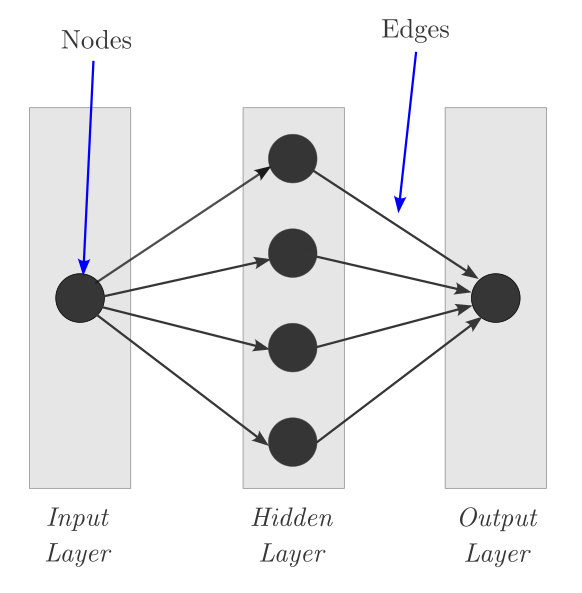

In a neural network, each layer computes a weighted sum of the inputs, adds a bias term and then applies an activation function (Sigmoid, ReLU etc).

The sigmoid activation function looks like this

$$g(z) = \frac{1}{1+e^{-z}}$$

Where

$$z ^ {[i]} = W^{[i]} g(z^{[i-1]}) + b^{[i]}$$

Here $W^{[i]}$ is the weight of the $i$-th layer and $b^{[i]}$ is the bias of the same layer.

Using this, it takes an input, calculates weights and biases and then outputs a result using an activation function. This is called the forward propagation. After outputing, it compares the prediction with real values and if the accuracy is low then it propagates backward and runs the layers again. For images we use Convolutional Neural Network (CNN) which has almost the same architecture as shown above but uses convolution theorem.

### Necessary Modules

In [8]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

### Load and Spliting Dataset

In [23]:
(ds_train, ds_test) = tfds.load('mnist', split=['train', 'test'], shuffle_files=True, as_supervised=True) # as_supervised=True ensures the dataset comes with (image, label) pairs

In [24]:
def normalize_img(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(normalize_img)
ds_test = ds_test.map(normalize_img)

In [13]:
# to improve performance we divide the whole dataset into chunks called batches
# Prefetching is a technique that allows you to prepare data for the next training step while the model is still training on the current batch.

BATCH_SIZE = 32
ds_train = ds_train.batch(BATCH_SIZE).prefetch(tf.data.experimental.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE).prefetch(tf.data.experimental.AUTOTUNE)

### CNN

In [14]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes (digits 0-9)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Training

In [16]:
# Train
EPOCHS = 10
history = model.fit(ds_train, epochs=EPOCHS, validation_data=ds_test)

# Evaluate
test_loss, test_acc = model.evaluate(ds_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Save
model.save("mnist_digit_recognizer.h5")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9099 - loss: 0.2932 - val_accuracy: 0.9832 - val_loss: 0.0515
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 19ms/step - accuracy: 0.9856 - loss: 0.0485 - val_accuracy: 0.9862 - val_loss: 0.0392
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9909 - loss: 0.0322 - val_accuracy: 0.9862 - val_loss: 0.0429
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9929 - loss: 0.0231 - val_accuracy: 0.9861 - val_loss: 0.0474
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9951 - loss: 0.0177 - val_accuracy: 0.9878 - val_loss: 0.0441
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9954 - loss: 0.0134 - val_accuracy: 0.9896 - val_loss: 0.0358
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9963 - loss: 0.0101 - val_accuracy: 0.9906 - val_loss: 0.0357
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9972 -

Test Accuracy: 0.9901


In [17]:
# Function to make predictions on new images
def predict_digit(image):
    image = np.expand_dims(image, axis=0)  # Expand dimensions to match model input
    image = np.expand_dims(image, axis=-1)  # Add channel dimension
    prediction = model.predict(image)
    predicted_label = np.argmax(prediction)
    return predicted_label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


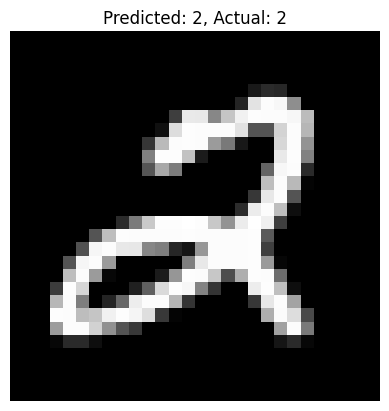

In [18]:
# Test prediction with a random sample from the dataset
for image, label in ds_test.take(1):
    image = image.numpy()
    label = label.numpy()
    predicted_label = predict_digit(image[0])

    plt.imshow(image[0], cmap="gray")
    plt.title(f"Predicted: {predicted_label}, Actual: {label[0]}")
    plt.axis("off")
    plt.show()

### Testing from User Input

In [25]:
from google.colab import files

In [26]:
# Load the saved model
model = tf.keras.models.load_model("mnist_digit_recognizer.h5")

In [27]:
# preprocess the uploaded image
def preprocess_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(28, 28), color_mode="grayscale")
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

Saving Screenshot 2025-03-08 120513.jpg to Screenshot 2025-03-08 120513 (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


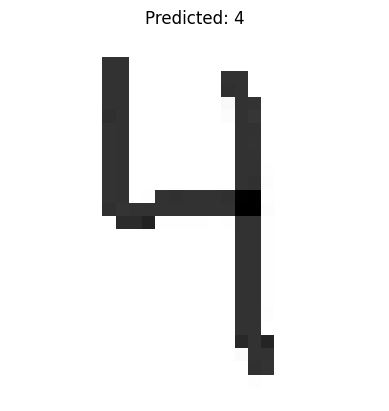

In [28]:
uploaded = files.upload()

for fn in uploaded.keys():

    image = preprocess_image(fn)

    prediction = model.predict(image)
    predicted_label = np.argmax(prediction)

    plt.imshow(image[0], cmap="gray")
    plt.title(f"Predicted: {predicted_label}")
    plt.axis("off")
    plt.show()
